![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 3. Interferometers I - MZI


Today we will work on the design and modeling of an **Mach-Zenhder Interferometer (MZI)** used in integrated photonic circuits. We will perform simulations that will allow us to understand how it operates.


## 0.1 General libraries

In [1]:
import gdsfactory as gf
#import jax
#import jax.example_libraries.optimizers as opt
#import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

C:\Users\cfp\AppData\Local\Temp\ipykernel_3944\3907569857.py:10: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 1. MZI modeling
Let's compute the transfer function of a MZI

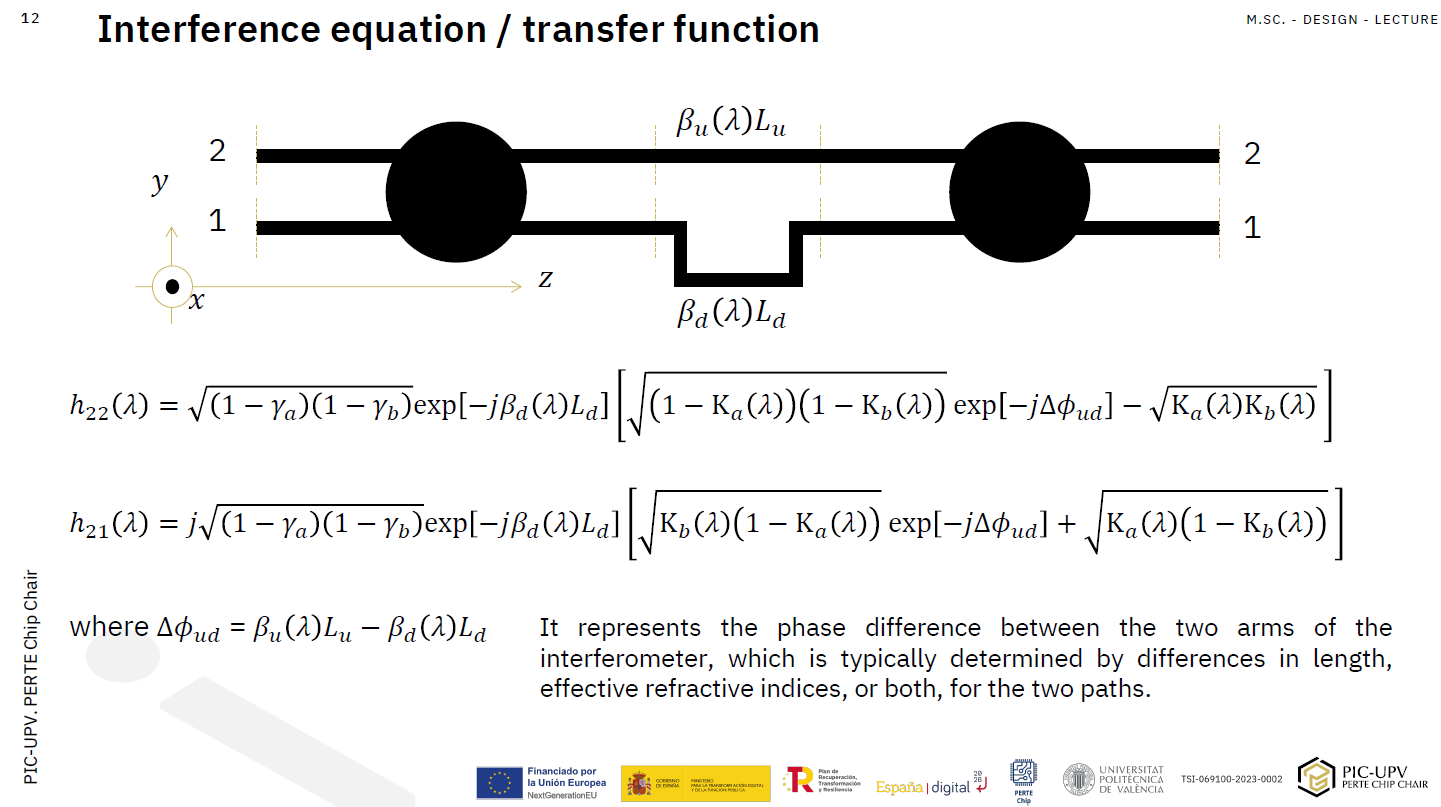

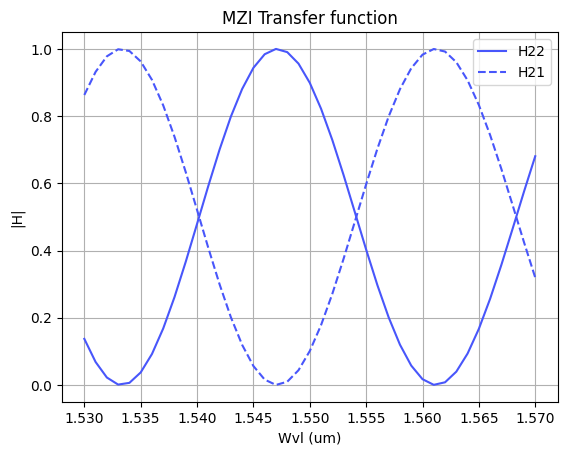

In [2]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 1.** Please, provide one example of each one of the configurations studied during MZI lecture:
1. Balenced configuration
2. Unbalanced configuration:
  1.   Phase difference
  2.   Delay imbalance

#### 1.1 Balanced configuration

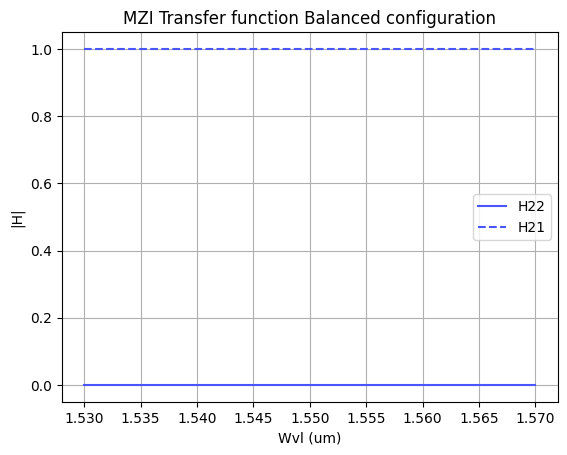

In [3]:
# Path length
Lu = 5; # um
Ld = 5; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function Balanced configuration')
plt.legend()
plt.grid(True)

plt.show()

#### 1.2. Unbalanced configuration

#### 1.2.1 Phase difference

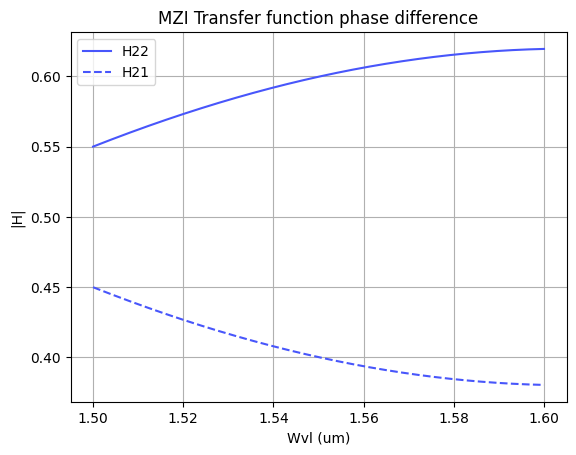

In [4]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')


#wvl = SOI[:, 0]
#neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
#neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function phase difference')
plt.legend()
plt.grid(True)

plt.show()

#### 1.2.2 Delay imbalance

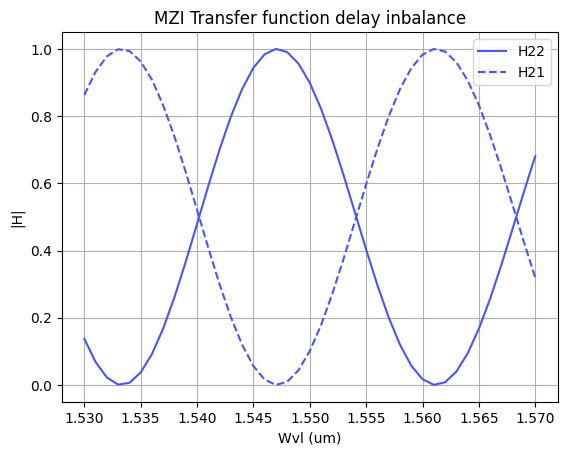

In [5]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function delay inbalance')
plt.legend()
plt.grid(True)

plt.show()

#### α=0.7


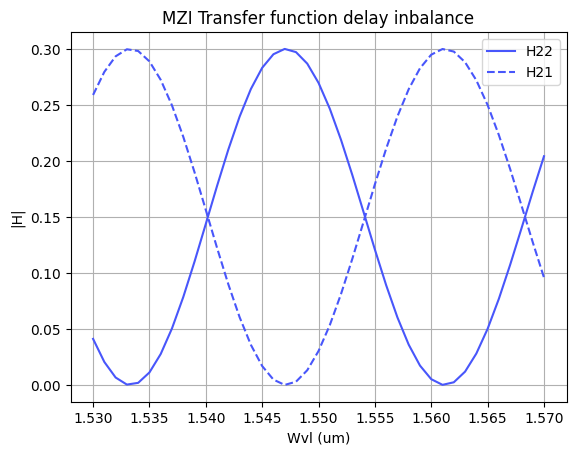

In [6]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0.7; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function delay inbalance')
plt.legend()
plt.grid(True)

plt.show()

#### γ=0.4


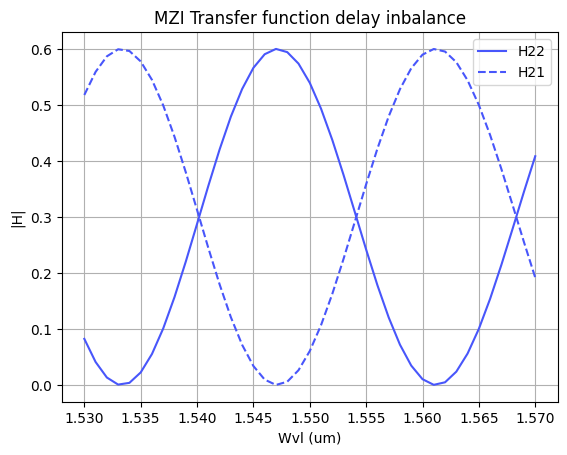

In [7]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0.4; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function delay inbalance')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 2.** Taking into account the n_{eff} values for the SOI cross-section, what would be the path difference ($\Delta L$ = $L_u$ - $L_d$) needed to obtain a Free Spectral Range of 40 nm? Introduce the obtained value in the model to check the MZI response. Hint: We assume 1550 nm as the central design wavelength ($\lambda _0$=1550 nm).

In [8]:
neffb= SOI[21, 3]
neff0= SOI[22, 3]
neffa= SOI[23, 3]

lb= SOI[21, 0]
l0= SOI[22, 0]
la= SOI[23, 0]

ng= neff0 - l0* (neffa - neffb)/ ( la - lb) 
FSR= 0.04  # um

variacion_l= (l0)**2/ (ng * FSR)

print( f' La variación de longitud per a un FSR de {FSR} um es: {variacion_l} um')

 La variación de longitud per a un FSR de 0.04 um es: 14.02604541526636 um


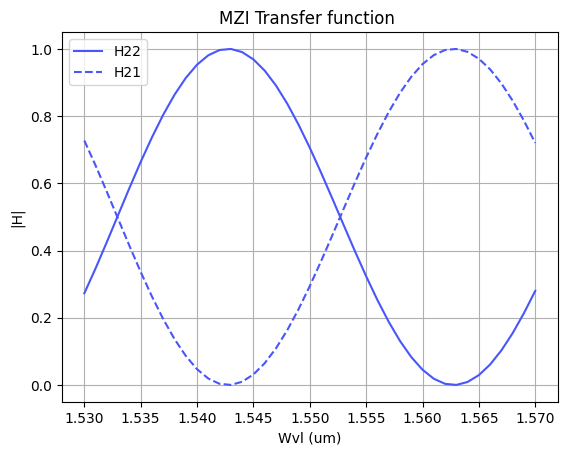

In [9]:
# Path length
Lu = 25; # um
Ld = Lu + variacion_l; # um

betau = (2*np.pi/wvl)*neffu-1j*alphau_np
betad = (2*np.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function ')
plt.legend()
plt.grid(True)

plt.show()

## 2. MZI simulation implemented with SAX
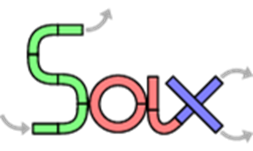

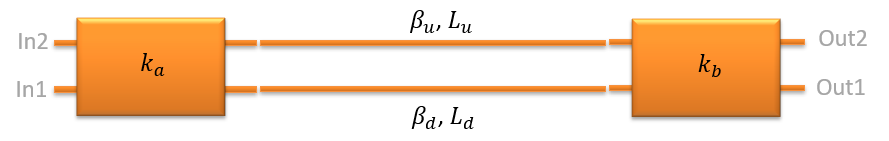


### 2.1 Components S matrix


In [10]:
# Waveguide Model

def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * np.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * np.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### 2.2 MZI SAX Circuit Model

In [11]:
# MZI

mzi, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u": "waveguide",
            "wvg_d": "waveguide",
            "coup_b": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0",
            "wvg_d,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u,in0",
            "wvg_u,out0": "coup_b,in1",
        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_b,out0",
            "out1": "coup_b,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


### 2.3. MZI Modeling
**Assesment 3**: Now, we are going to implement the design parameters in the MZI model developed in SAX and compare the response obtained with that simulated by mathematical formulation.

This will help us to identify any error in the definition of the SAX model single components.

In order to implement the SAX model, take as example the following lines:

    mzi_test = mzi(wl=wl,
                coup_a = ...
                wvg_d={"length": l_d, "neff": ...},
                wvg_u={"length": l_u, "neff": ...},
                coup_b = ... )

    H00 = mzi_test["in0", "out0"]

##### 3.1 Balanced configuration

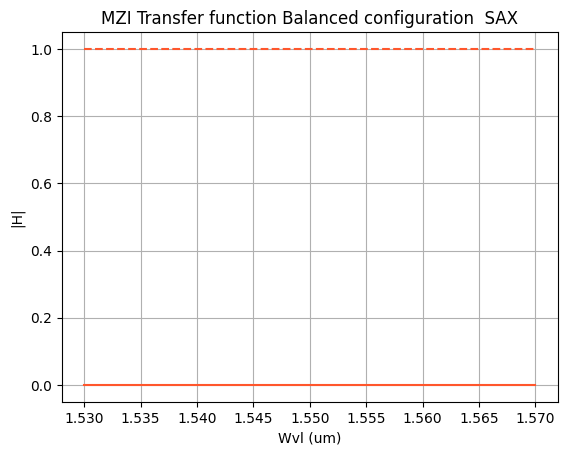

In [22]:
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 5; # um
Ld = 5; # um

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)


mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": Lu, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": Ld, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h11 = mzi_test["in1", "out1"]
h10 = mzi_test["in1", "out0"]


# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", color=color[8], label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", color=color[8], label=f"h10")
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function Balanced configuration  SAX')
plt.grid(True)
plt.show()




##### 3.2. Unbalanced configuration

#### 3.2.1 Phase difference

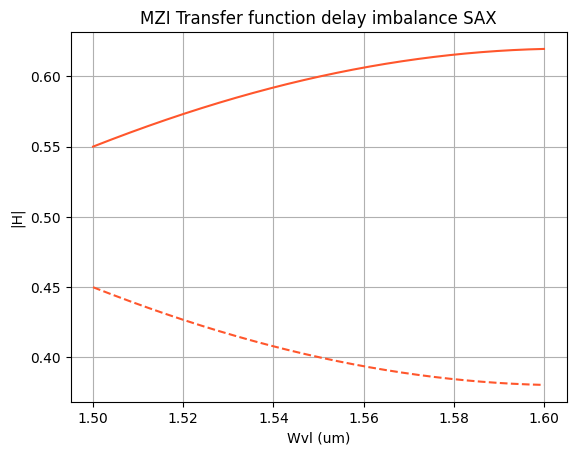

In [23]:
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 25; # um


# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": Lu, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": Ld, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h11 = mzi_test["in1", "out1"]
h10 = mzi_test["in1", "out0"]


# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", color=color[8], label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", color=color[8], label=f"h10")
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function delay imbalance SAX')
plt.grid(True)
plt.show()


##### 3.2.2 Delay Imbalance

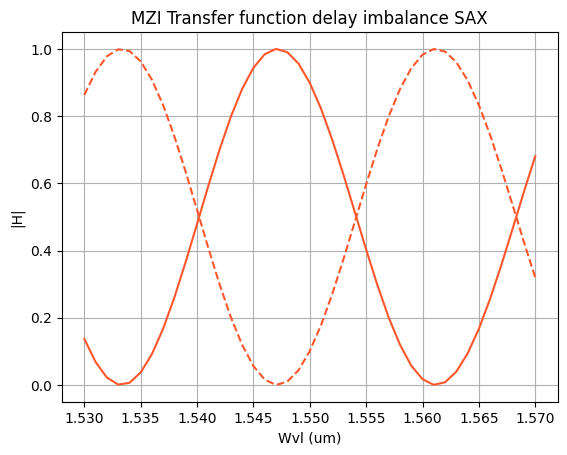

In [20]:
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

# Propagation loss
alphau = 0 #losless case [dB/um]
alphad = 0; #losless case [dB/um]
alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25; # um
Ld = 5; # um

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)


mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": Lu, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": Ld, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h11 = mzi_test["in1", "out1"]
h10 = mzi_test["in1", "out0"]


# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", color=color[8], label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", color=color[8], label=f"h10")
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function delay imbalance SAX')
plt.grid(True)
plt.show()



**Assessment 4.** Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.

**Assessment 5.** Let's see how the response of the MZI variates with the effective index. Vary the effective index of one of the arms and analyze how the spectrum shifts. To do this, you can use the data provided in the .txt files entitled ‘SiN’.
Can you give an example of an application where this configuration is used?

**Assessment 6.** Explore how cascading two MZIs affects the transmission spectrum. To do so, design a system in which two MZIs are cascaded. Simulate and observe the spectrum, explaining how the transmission peaks behave.

Potencia en 1550nm por el puerto BAR: 0.9999985915967108
Diferencia de caminos: 20.0675 um


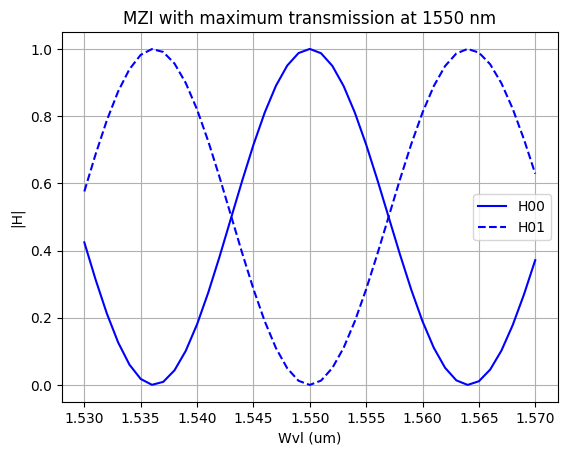

In [ ]:
#Assesment 4
wvl = SOI[:, 0]
neffu = SOI[:, 3] #balanced configuration // (neff TE mode)
neffd = SOI[:, 3] #balanced configuration // (neff TE mode)

alphau = 0.0 #losless case [dB/um]
alphad = 0.0; #losless case [dB/um]

alphau_np = (np.log(10.0)/20.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/20.0) * alphad   # neper/um

# Path length
Lu = 4.9325; # um
Ld = 25 ; # um


# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": Lu, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": Ld, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h10 = mzi_test["in1", "out0"]
h11 = mzi_test["in1", "out1"]

H00 = np.abs(h00) ** 2
H01 = np.abs(h01) ** 2
H10 = np.abs(h10) ** 2
H11 = np.abs(h11) ** 2

print("Potencia en 1550nm por el puerto BAR:", H00[20],)
print("Diferencia de caminos:" , Ld-Lu, "um")

# Plot
plt.figure()
#plt.plot(wvl, np.abs(h11)**2,"red",  linestyle="-", label=f"h11")
#plt.plot(wvl, np.abs(h10)**2,"red", linestyle="--", label=f"h10")
plt.plot(wvl, H00,"blue", linestyle='-', label='H00')
plt.plot(wvl, H01,"blue",  linestyle='--', label='H01')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI with maximum transmission at 1550 nm')
plt.grid(True)
plt.legend()
plt.show()


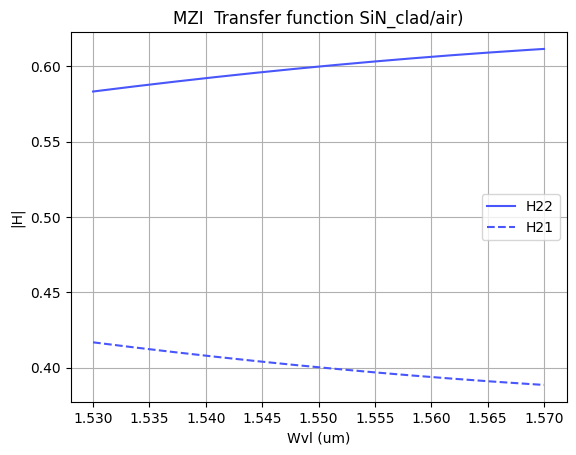

In [ ]:
#Assesment 5

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')


SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] 
neffu0 = SiN_clad[:, 3] 
neffd0 = SiN_air[:, 3]


interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')

wvl = np.linspace(wvl.min(), wvl.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

# Propagation loss
alphau = 0.0 #losless case [dB/um]
alphad = 0.0; #losless case [dB/um]

alphau_np = (np.log(10.0)/10.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/10.0) * alphad   # neper/um

# Path length
Lu = 25 ; # um
Ld = 25 ; # um


# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

mzi_test = mzi(wl=wvl,
            coup_a={"coupling":K_a},
            wvg_u={"wl":wvl, "neff":neffu, "length": Lu, "loss":alphau},
            wvg_d={"wl":wvl, "neff":neffd, "length": Ld, "loss":alphad},
            coup_b={"coupling":K_b},
            )

h00 = mzi_test["in0", "out0"]
h01 = mzi_test["in0", "out1"]
h10 = mzi_test["in1", "out0"]
h11 = mzi_test["in1", "out1"]

H00 = np.abs(h00) ** 2
H01 = np.abs(h01) ** 2
H10 = np.abs(h10) ** 2
H11 = np.abs(h11) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI  Transfer function SiN_clad/air)')
plt.legend()
plt.grid(True)
plt.show()